# Evaluasi Model IndoBERT untuk Klasifikasi Tingkat Krisis Mahasiswa

In [1]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import DataLoader, Dataset
from tqdm.notebook import tqdm
from google.colab import drive

drive.mount('/content/drive')

DRIVE_BASE = "/content/drive/MyDrive/PA 3 KEL 10-20260406T061058Z-3-001/PA 3 KEL 10/Dataset"
MODEL_DIR = f"{DRIVE_BASE}/pa3_indobert_final_v2"
CSV_PATH  = f"{DRIVE_BASE}/train_dataset_baru.csv"
BATCH_SIZE = 16

Mounted at /content/drive


In [2]:
df = pd.read_csv(CSV_PATH)
texts  = df['text_clean'].astype(str).tolist()
labels = df['final_level'].astype(int).tolist()

print("--- DISTRIBUSI DATASET ---")
print(f"Total Dataset: {len(texts)} data")
print(df['final_level'].value_counts().sort_index())

train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

print("\n--- PEMBAGIAN DATASET (SPLIT 80:20) ---")
print(f"Total Data Training : {len(train_texts)} data")
print(f"Total Data Validasi : {len(val_texts)} data")

--- DISTRIBUSI DATASET ---
Total Dataset: 4793 data
final_level
0    1126
1    3577
2      78
3      12
Name: count, dtype: int64

--- PEMBAGIAN DATASET (SPLIT 80:20) ---
Total Data Training : 3834 data
Total Data Validasi : 959 data


## Memuat Model dan Tokenizer

In [3]:
print("Memuat Model dan Tokenizer...")
tokenizer = BertTokenizer.from_pretrained("indobenchmark/indobert-base-p1")
model = BertForSequenceClassification.from_pretrained(MODEL_DIR)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()
print(f"Model berhasil dimuat ke: {device}")

Memuat Model dan Tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model berhasil dimuat ke: cuda


## Menjalankan Prediksi pada Data Validasi

In [4]:
class EvalDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

val_dataset = EvalDataset(val_texts, val_labels, tokenizer)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

predictions = []
true_labels = []

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Evaluasi"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        _, preds = torch.max(outputs.logits, dim=1)

        predictions.extend(preds.cpu().tolist())
        true_labels.extend(labels.cpu().tolist())
        
print("Prediksi Selesai!")

Evaluasi:   0%|          | 0/60 [00:00<?, ?it/s]

Prediksi Selesai!


## Hasil Akurasi & Classification Report

Accuracy Keseluruhan: 0.9343 (93.43%)

Classification Report:
                      precision    recall  f1-score   support

    Level 0 (Normal)       0.84      0.91      0.87       225
Level 1 (Pemantauan)       0.97      0.95      0.96       716
 Level 2 (Perhatian)       1.00      0.81      0.90        16
    Level 3 (Krisis)       1.00      0.50      0.67         2

            accuracy                           0.93       959
           macro avg       0.95      0.79      0.85       959
        weighted avg       0.94      0.93      0.93       959


[INFO] Menggunakan fallback data riwayat training.
TRAINING & VALIDATION LOSS (History dari Training)
Epoch 1 | Train Loss: 0.7530 | Val Loss: 0.4498
Epoch 2 | Train Loss: 0.3831 | Val Loss: 0.4314 (TERBAIK)
Epoch 3 | Train Loss: 0.1539 | Val Loss: 0.4779
Epoch 4 | Train Loss: 0.0698 | Val Loss: 0.6538
Epoch 5 | Train Loss: 0.0046 | Val Loss: 0.7072 (OVERFITTING)


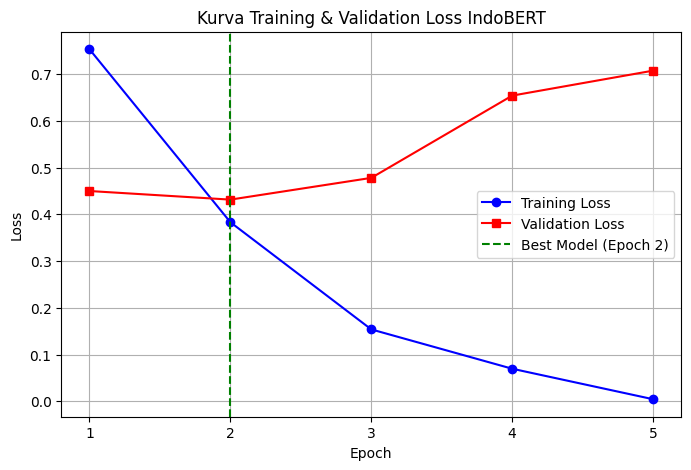

In [5]:
accuracy = accuracy_score(true_labels, predictions)
print(f"Accuracy Keseluruhan: {accuracy:.4f} ({accuracy*100:.2f}%)\n")

target_names = ['Level 0 (Normal)', 'Level 1 (Pemantauan)', 'Level 2 (Perhatian)', 'Level 3 (Krisis)']
print("Classification Report:")
print(classification_report(true_labels, predictions, target_names=target_names))

import os
import pandas as pd
import matplotlib.pyplot as plt

fallback_data = [
    {"epoch": 1, "train_loss": 0.7530, "val_loss": 0.4498},
    {"epoch": 2, "train_loss": 0.3831, "val_loss": 0.4314},
    {"epoch": 3, "train_loss": 0.1539, "val_loss": 0.4779},
    {"epoch": 4, "train_loss": 0.0698, "val_loss": 0.6538},
    {"epoch": 5, "train_loss": 0.0046, "val_loss": 0.7072}
]

csv_locations = [
    os.path.join(MODEL_DIR, "training_history.csv") if "MODEL_DIR" in locals() else "",
    "training_history.csv",
    "training/training_history.csv",
    "pa3_indobert_final/training_history.csv",
    os.path.join(DRIVE_BASE, "training_history.csv") if "DRIVE_BASE" in locals() else ""
]

df_history = None
for loc in csv_locations:
    if loc and os.path.exists(loc):
        try:
            df_history = pd.read_csv(loc)
            print(f"\n[INFO] Berhasil memuat riwayat training dari: {loc}")
            break
        except Exception:
            pass

if df_history is None:
    df_history = pd.DataFrame(fallback_data)
    print("\n[INFO] Menggunakan fallback data riwayat training.")

print("==================================================")
print("TRAINING & VALIDATION LOSS (History dari Training)")
print("==================================================")
for _, row in df_history.iterrows():
    epoch = int(row["epoch"])
    t_loss = row["train_loss"]
    v_loss = row["val_loss"]
    status = ""
    if epoch == 2:
        status = " (TERBAIK)"
    elif epoch == 5:
        status = " (OVERFITTING)"
    print(f"Epoch {epoch} | Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f}{status}")

plt.figure(figsize=(8, 5))
plt.plot(df_history["epoch"], df_history["train_loss"], marker="o", label="Training Loss", color="blue")
plt.plot(df_history["epoch"], df_history["val_loss"], marker="s", label="Validation Loss", color="red")
plt.axvline(x=2, color="green", linestyle="--", label="Best Model (Epoch 2)")
plt.title("Kurva Training & Validation Loss IndoBERT")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(df_history["epoch"])
plt.legend()
plt.grid(True)
plt.savefig("loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

## Visualisasi Confusion Matrix
Grafik ini menunjukkan prediksi benar (diagonal utama) vs prediksi salah model.

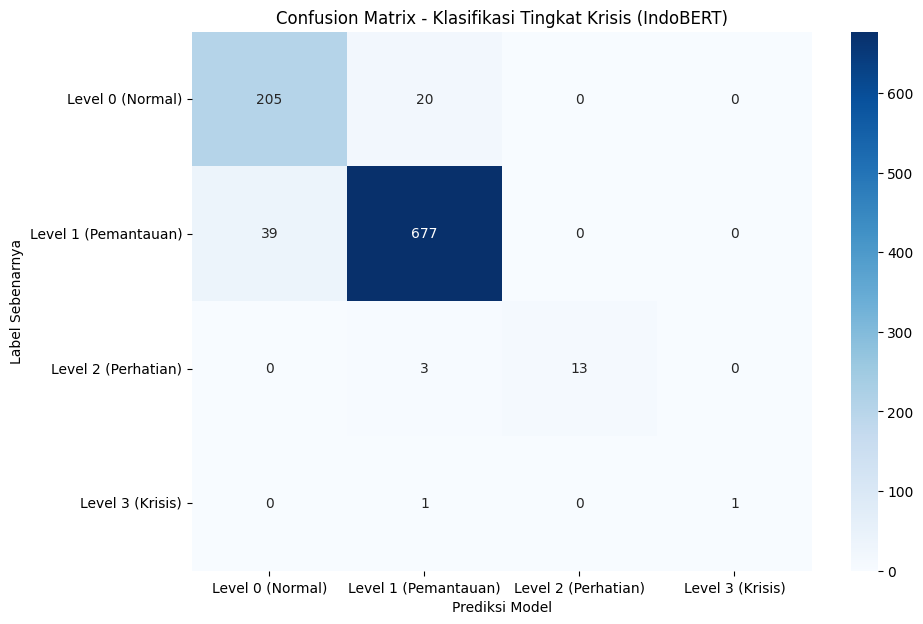

In [6]:
cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Prediksi Model')
plt.ylabel('Label Sebenarnya')
plt.title('Confusion Matrix - Klasifikasi Tingkat Krisis (IndoBERT)')
plt.show()